In [1]:
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt

In [2]:
results_dir = os.path.expanduser("~/Desktop/Danish/CMIP Prediction Results/Ba/Absolute/")
variable    = "Ba"

glaciernames = ['Alfotbreen', 'Austdalsbreen', 'Engabreen', 'Grafjellsbrea', 'Grasubreen', 
                             'Hansebreen', 'Hellstugubreen', 'Langfjordjokelen', 'Nigardsbreen', 'Rembesdalskaka', 'Storbreen']

glaciers = {} 

# climatology windows
windows = [
    ("Near-future", 2025, 2040),
    ("Mid-century", 2041, 2060),
    ("Late-century", 2080, 2100),
]

pred_path= os.path.join(results_dir, f"{variable}_cmip6_predictions_ALL.csv")

ssp_cols = ["Predicted_SSP1_2.6", "Predicted_SSP2_4.5", "Predicted_SSP5_8.5"]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

### Heat maps

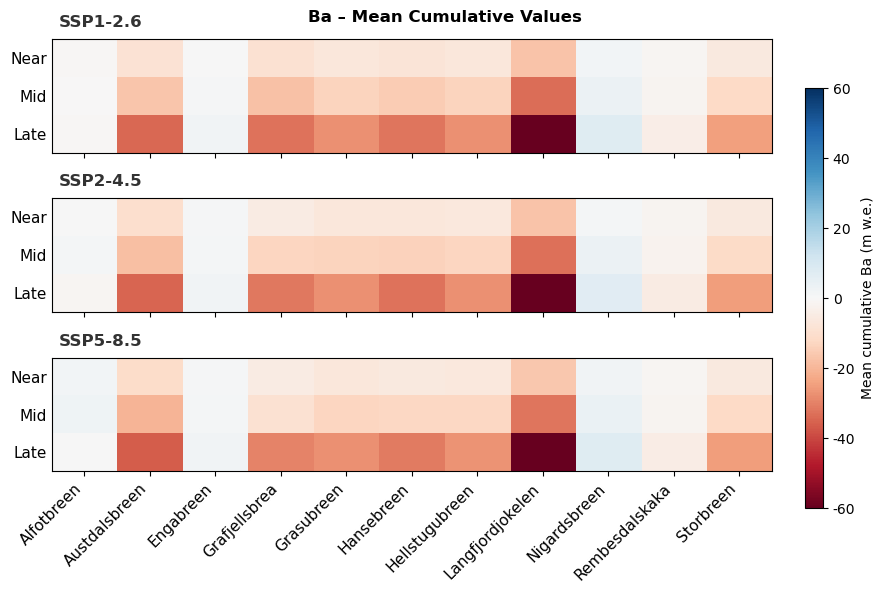

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from matplotlib.colors import TwoSlopeNorm

# === SETTINGS ===
root_dir = os.path.expanduser("~/Desktop/Danish/CMIP Prediction Results")
variable = "Ba"

glaciernames = [
     'Alfotbreen','Austdalsbreen','Engabreen','Grafjellsbrea','Grasubreen',
     'Hansebreen','Hellstugubreen','Langfjordjokelen','Nigardsbreen',
     'Rembesdalskaka','Storbreen']

ssp_cols   = ["Predicted_SSP1_2.6","Predicted_SSP2_4.5","Predicted_SSP5_8.5"]
ssp_labels = ["SSP1-2.6","SSP2-4.5","SSP5-8.5"]
windows    = [("Near",2025,2040),("Mid",2041,2060),("Late",2080,2100)]

# === LOAD DATA ===
fpath = os.path.join(root_dir, variable, "Attempt_12_07", f"{variable}_cmip6_predictions_ALL.csv")
df = pd.read_csv(fpath)

date_col = "date" if "date" in df.columns else "Date"
df.rename(columns={date_col: "date"}, inplace=True)
df["date"] = pd.to_datetime(df["date"])
df["Year"] = df["date"].dt.year

# === ANNUAL AND CUMULATIVE AGGREGATION ===
ann = df.groupby(["Glacier", "Year"])[ssp_cols].mean().reset_index()   # mean, not sum

cum = ann.sort_values("Year").groupby("Glacier")[ssp_cols].cumsum()
cum_df = ann[["Glacier","Year"]].join(cum)

# === PLOT SETUP ===
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

sym_limit = 60
norm = TwoSlopeNorm(vcenter=0, vmin=-sym_limit, vmax=sym_limit)

for ax, ssp, label in zip(axes, ssp_cols, ssp_labels):
    matrices, row_labels = [], []
    for win_label, y0, y1 in windows:
        sub = cum_df.query(f"{y0} <= Year <= {y1}")
        mean = sub.groupby("Glacier")[ssp].mean().reindex(glaciernames)
        matrices.append(mean.values)
        row_labels.append(win_label)
    data = np.vstack(matrices)

    im = ax.imshow(data, cmap="RdBu", aspect="auto", norm=norm)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=11)

    ax.text(0.01, 1.08, label, transform=ax.transAxes,
        fontsize=12, fontweight="bold", color="#333333",
        ha="left", va="bottom")

    ax.tick_params(axis="y", length=0)
    ax.grid(False)

axes[-1].set_xticks(np.arange(len(glaciernames)))
axes[-1].set_xticklabels(glaciernames, rotation=45, ha="right", fontsize=11)

fig.tight_layout(rect=[0, 0, 0.88, 1])
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Mean cumulative Ba (m w.e.)", fontsize=10)

cbar.ax.minorticks_off()
cbar.set_ticks([-60, -40, -20, 0, 20, 40, 60])
cbar.ax.yaxis.set_major_formatter(mticker.FixedFormatter(
    ["-60", "-40", "-20", "0", "20", "40", "60"]))

fig.suptitle(f"{variable} – Mean Cumulative Values", fontsize=12, weight="bold")

#plt.savefig(f"/Users/sda/Desktop/Danish/Py-Plots/18-Paper_Plots/Ba_Mean_Cumulative_Anomalies_Heatmap.png", dpi=800)
plt.show()

In [4]:
for glacier in glaciernames:
    sub = cum_df[cum_df["Glacier"] == glacier]
    for win_label, y0, y1 in windows:
        val = sub.query(f"{y0} <= Year <= {y1}")["Predicted_SSP1_2.6"].mean()
        print(f"{glacier:20s} {win_label:5s}: {val:.2f}")

Alfotbreen           Near : -0.53
Alfotbreen           Mid  : -0.07
Alfotbreen           Late : -0.54
Austdalsbreen        Near : -8.89
Austdalsbreen        Mid  : -16.62
Austdalsbreen        Late : -34.40
Engabreen            Near : 0.35
Engabreen            Mid  : 0.91
Engabreen            Late : 2.16
Grafjellsbrea        Near : -9.00
Grafjellsbrea        Mid  : -17.72
Grafjellsbrea        Late : -32.44
Grasubreen           Near : -6.76
Grasubreen           Mid  : -13.35
Grasubreen           Late : -27.65
Hansebreen           Near : -7.75
Hansebreen           Mid  : -15.07
Hansebreen           Late : -32.14
Hellstugubreen       Near : -6.70
Hellstugubreen       Mid  : -13.19
Hellstugubreen       Late : -27.39
Langfjordjokelen     Near : -16.89
Langfjordjokelen     Mid  : -33.37
Langfjordjokelen     Late : -69.25
Nigardsbreen         Near : 1.60
Nigardsbreen         Mid  : 3.60
Nigardsbreen         Late : 7.34
Rembesdalskaka       Near : -1.36
Rembesdalskaka       Mid  : -1.85
Rembesd

### Sliced fig; only one SSP (2-4.5)

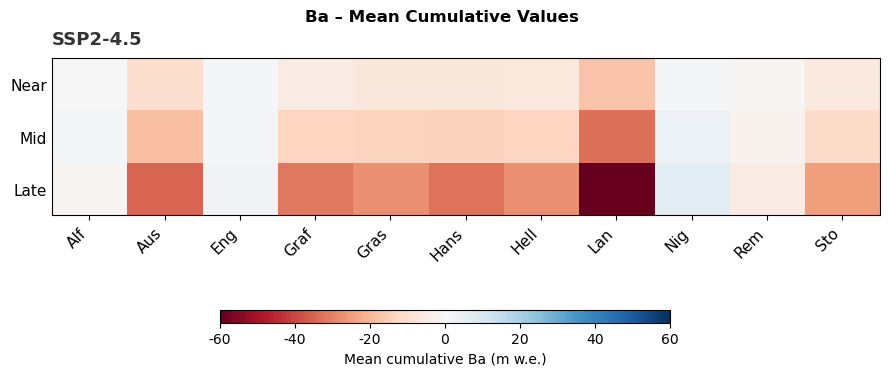

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from matplotlib.colors import TwoSlopeNorm

# === SETTINGS ===
root_dir = os.path.expanduser("~/Desktop/Danish/CMIP Prediction Results")
variable = "Ba"

glaciernames = [
     'Alfotbreen','Austdalsbreen','Engabreen','Grafjellsbrea','Grasubreen',
     'Hansebreen','Hellstugubreen','Langfjordjokelen','Nigardsbreen',
     'Rembesdalskaka','Storbreen']

glacier_labels_short = ['Alf', 'Aus','Eng','Graf','Gras',
     'Hans','Hell','Lan','Nig',
     'Rem','Sto']

ssp_col   = "Predicted_SSP2_4.5"
ssp_label = "SSP2-4.5"
windows   = [("Near",2025,2040),("Mid",2041,2060),("Late",2080,2100)]

# === LOAD DATA ===
fpath = os.path.join(root_dir, variable, "Attempt_12_07", f"{variable}_cmip6_predictions_ALL.csv")
df = pd.read_csv(fpath)

date_col = "date" if "date" in df.columns else "Date"
df.rename(columns={date_col: "date"}, inplace=True)
df["date"] = pd.to_datetime(df["date"])
df["Year"] = df["date"].dt.year

# === ANNUAL AND CUMULATIVE AGGREGATION ===
ann = df.groupby(["Glacier", "Year"])[[ssp_col]].mean().reset_index()   # mean, not sum

cum = ann.sort_values("Year").groupby("Glacier")[[ssp_col]].cumsum()
cum_df = ann[["Glacier","Year"]].join(cum)

# === PLOT SETUP ===
fig, ax = plt.subplots(figsize=(9, 3.2))

sym_limit = 60
norm = TwoSlopeNorm(vcenter=0, vmin=-sym_limit, vmax=sym_limit)

matrices, row_labels = [], []
for win_label, y0, y1 in windows:
    sub = cum_df.query(f"{y0} <= Year <= {y1}")
    
    mean = sub.groupby("Glacier")[ssp_col].mean().reindex(glaciernames)
    matrices.append(mean.values)
    row_labels.append(win_label)
data = np.vstack(matrices)

im = ax.imshow(data, cmap="RdBu", aspect="auto", norm=norm)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=11)

ax.set_title(ssp_label, fontsize=13, fontweight="bold", color="#333333",
             loc="left", pad=10)

ax.tick_params(axis="y", length=0)
ax.grid(False)

ax.set_xticks(np.arange(len(glaciernames)))
# --- use short labels here for display only ---
ax.set_xticklabels(glacier_labels_short, rotation=45, ha="right", fontsize=11)

fig.tight_layout(rect=[0, 0.18, 1, 1])
cax = fig.add_axes([0.25, 0.04, 0.5, 0.04])
cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
cbar.set_label("Mean cumulative Ba (m w.e.)", fontsize=10)

cbar.ax.minorticks_off()
cbar.set_ticks([-60, -40, -20, 0, 20, 40, 60])
cbar.ax.xaxis.set_major_formatter(mticker.FixedFormatter(
    ["-60", "-40", "-20", "0", "20", "40", "60"]))

fig.suptitle(f"{variable} – Mean Cumulative Values ",
             fontsize=12, weight="bold", y=1.02)

#plt.savefig(f"/Users/sda/Desktop/Danish/Py-Plots/18-Paper_Plots/Ba_cumulative_SSP4.5_Heatmap.png", bbox_inches="tight", dpi=800)
plt.show()

### Cumulative Ba: Line Plots

### loading Variables for the lineplots

In [6]:
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt

results_dir = os.path.expanduser("~/Desktop/Danish/CMIP Prediction Results/Ba/Attempt_12_07")
variable    = "Ba"

glaciernames = ['Alfotbreen', 'Austdalsbreen', 'Engabreen', 'Grafjellsbrea', 'Grasubreen', 
                             'Hansebreen', 'Hellstugubreen', 'Langfjordjokelen', 'Nigardsbreen', 'Rembesdalskaka', 'Storbreen']

glaciers = {} 

# climatology windows
windows = [
    ("Near-future", 2025, 2040),
    ("Mid-century", 2041, 2060),
    ("Late-century", 2080, 2100),
]

pred_path= os.path.join(results_dir, f"{variable}_cmip6_predictions_ALL.csv")
obs_path = os.path.join(results_dir, f"{variable}_era5_obs_and_predictions_ALL_Voting.csv")

ssp_cols = ["Predicted_SSP1_2.6", "Predicted_SSP2_4.5", "Predicted_SSP5_8.5"]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]



/var/folders/z6/ywzybcnn45l5s5dwpjwks0y40000gn/T/ipykernel_35787/1738337420.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(glaciernames))


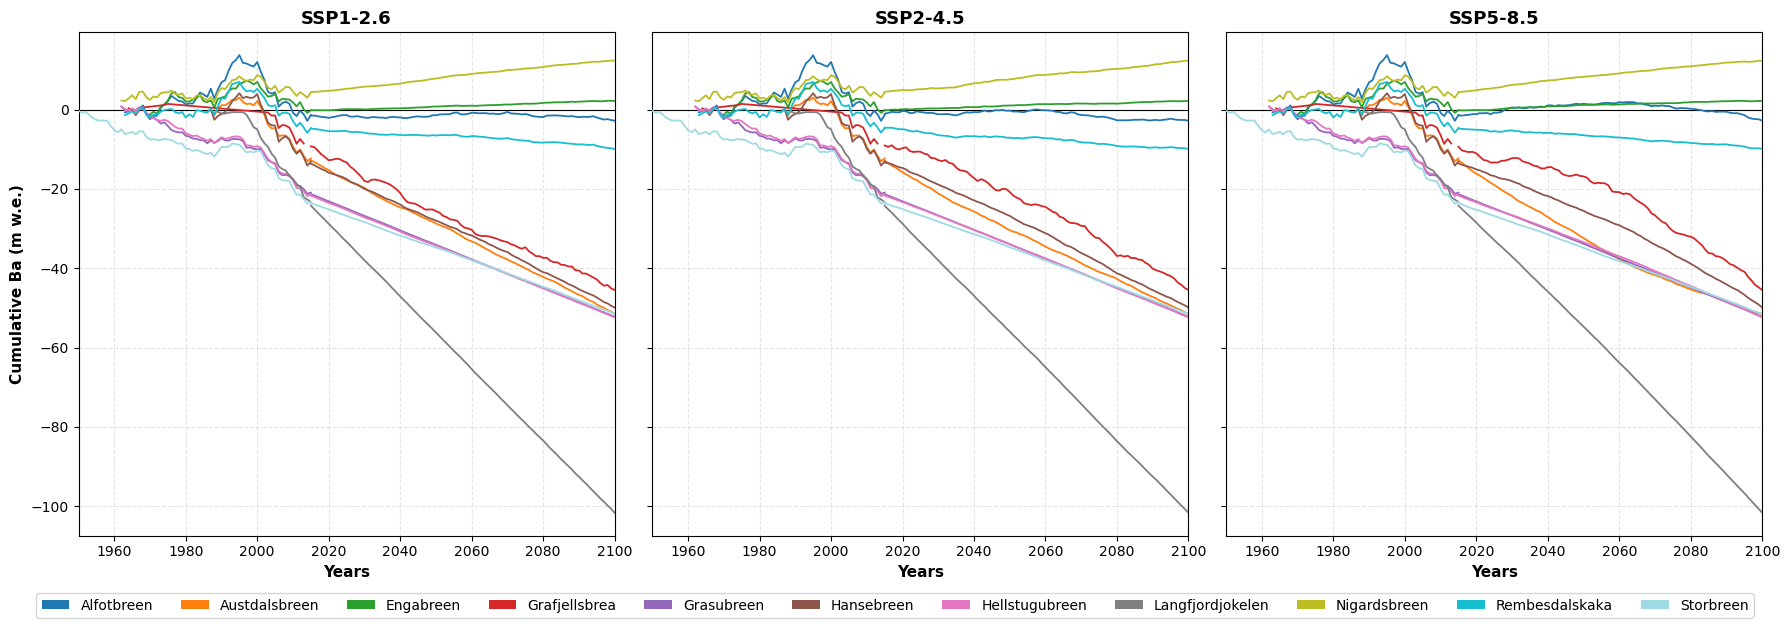

In [7]:
## FINAL PLOT CODE THATS USED IN THE PAPER

import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
import matplotlib.cm as cm
from matplotlib.patches import Patch


# --- read files ---
pred = pd.read_csv(pred_path, parse_dates=["Date"], dayfirst=True)
obs  = pd.read_csv(obs_path,  parse_dates=["Date"], dayfirst=True)

ssp_cols = ["Predicted_SSP1_2.6","Predicted_SSP2_4.5","Predicted_SSP5_8.5"]
obs_col  = "obs anomalies"
break_year = 2000

# --- prepare to annual ---
pred = pred.sort_values("Date").set_index("Date")
obs  = obs.sort_values("Date").set_index("Date")

pred_yr = (
    pred.assign(Year=pred.index.year)
        .groupby(["Glacier", "Year"])[ssp_cols].mean()   # mean, not sum
        .reset_index()
        .assign(Date=lambda d: pd.to_datetime(d["Year"], format="%Y"))
        .drop(columns="Year")
)
obs_yr = obs.reset_index()

# === compute cumulative anomalies ===
pred_cum = (
    pred_yr.sort_values("Date")
            .groupby("Glacier")[ssp_cols]
            .cumsum()
            .join(pred_yr[["Glacier","Date"]])
)
obs_cum = (
    obs_yr.sort_values("Date")
          .groupby("Glacier")[obs_col]
          .cumsum()
          .to_frame(name="Cumulative_obs")
          .join(obs_yr[["Glacier","Date"]])
)

# anchor pred_cum to continue from where obs_cum leaves off (no boundary reset)
pred_cum_adj = pred_cum.copy()

for glacier in glaciernames:
    gobs = obs_cum.loc[obs_cum["Glacier"] == glacier].sort_values("Date")
    gpred_mask = pred_cum_adj["Glacier"] == glacier
    gpred = pred_cum_adj.loc[gpred_mask].sort_values("Date")

    if gobs.empty or gpred.empty:
        continue

    ssp_start_year = int(gpred["Date"].dt.year.min())
    obs_at_boundary = gobs.loc[gobs["Date"].dt.year <= ssp_start_year, "Cumulative_obs"]
    if obs_at_boundary.empty:
        continue
    offset = obs_at_boundary.iloc[-1]

    for ssp in ssp_cols:
        pred_cum_adj.loc[gpred_mask, ssp] = pred_cum_adj.loc[gpred_mask, ssp] + offset

pred_cum = pred_cum_adj


cmap = cm.get_cmap("tab20", len(glaciernames))
glacier_colors = {g: cmap(i) for i, g in enumerate(glaciernames)}

ssp_titles = {
    "Predicted_SSP1_2.6": "SSP1-2.6",
    "Predicted_SSP2_4.5": "SSP2-4.5",
    "Predicted_SSP5_8.5": "SSP5-8.5",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

for ax, ssp in zip(axes, ssp_cols):
    for glacier in glaciernames:
        gobs  = obs_cum.loc[obs_cum["Glacier"] == glacier, ["Date", "Cumulative_obs"]].set_index("Date")
        gpred = pred_cum.loc[pred_cum["Glacier"] == glacier, ["Date", ssp]].set_index("Date")

        ssp_valid = gpred[ssp].dropna()
        if ssp_valid.empty:
            continue
        ssp_start_year = int(ssp_valid.index.year.min())

        if not gobs.empty:
            obs_mask = gobs.index.year <= ssp_start_year
            if obs_mask.any():
                ax.plot(gobs.index[obs_mask], gobs["Cumulative_obs"][obs_mask],
                        color=glacier_colors[glacier], lw=1.3, zorder=3)

        ax.plot(gpred.index, gpred[ssp],
                 color=glacier_colors[glacier], lw=1.3,
                 label=glacier, zorder=3)

    ax.axhline(0, color="k", lw=0.8)
    ax.xaxis.set_major_locator(YearLocator(20))
    ax.xaxis.set_major_formatter(DateFormatter("%Y"))
    ax.set_xlim(pd.Timestamp("1950-01-01"), pd.Timestamp("2100-01-01"))
    ax.set_title(ssp_titles[ssp], fontsize=13, fontweight="bold")
    ax.set_xlabel("Years", fontsize=11, fontweight="bold")
    ax.grid(True, linestyle="--", color="#d3d3d3", alpha=0.6)

axes[0].set_ylabel(f"Cumulative {variable} (m w.e.)", fontsize=11, fontweight="bold")

legend_handles = [Patch(facecolor=glacier_colors[g], edgecolor="none", label=g) for g in glaciernames]
fig.legend(handles=legend_handles, loc="lower center", ncol=len(glaciernames),
           bbox_to_anchor=(0.5, -0.05), frameon=True, fontsize=10)

plt.tight_layout()
#plt.savefig(f"/Users/sda/Desktop/Danish/Py-Plots/18-Paper_Plots/{variable}_Cumulative_Anomalies_All_Glaciers.png", dpi=800, bbox_inches="tight")
plt.show()

In [8]:
pred_yr_sorted = pred_yr.sort_values(["Glacier", "Date"]).reset_index(drop=True)
cumsum_direct = pred_yr_sorted.groupby("Glacier")[ssp_cols].cumsum()
check = pred_yr_sorted[["Glacier", "Date"]].join(cumsum_direct)
nigards_check = check[(check["Glacier"] == "Nigardsbreen") & (check["Date"].dt.year == 2040)]
print(nigards_check)

          Glacier       Date  Predicted_SSP1_2.6  Predicted_SSP2_4.5  \
713  Nigardsbreen 2040-01-01            2.217207            2.303912   

     Predicted_SSP5_8.5  
713            3.012968  
